In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from src.config import PROCESSED_DATA_PATH

In [5]:
df = pd.read_csv(PROCESSED_DATA_PATH)

In [45]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,credit_history_years,loan_default
0,9600.0,36 months,12.99,323.42,C,C1,NaN,RENT,21900.0,Verified,...,10.03,0.0,13.0,1.0,4509.0,38.9,20.0,Individual,13.081451,0
1,4000.0,36 months,6.68,122.93,A,A3,4.0,MORTGAGE,83000.0,Not Verified,...,19.53,0.0,16.0,0.0,1564.0,17.2,25.0,Individual,11.581109,0
2,6025.0,36 months,10.91,197.00,B,B4,10.0,RENT,52000.0,Not Verified,...,9.16,1.0,11.0,0.0,2706.0,12.8,25.0,Individual,12.501027,0
3,20000.0,36 months,9.49,640.57,B,B2,10.0,MORTGAGE,100000.0,Not Verified,...,16.43,1.0,15.0,0.0,20440.0,56.3,32.0,Individual,26.001369,0
4,1000.0,36 months,8.18,31.42,B,B1,NaN,RENT,23000.0,Verified,...,16.34,1.0,6.0,0.0,3237.0,77.1,38.0,Individual,28.580424,0


In [6]:
df.shape

(71348, 21)

In [50]:
df['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [51]:
df['term'] = df['term'].str.replace(' months', '').astype(int)

In [52]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,credit_history_years,loan_default
0,9600.0,36,12.99,323.42,C,C1,NaN,RENT,21900.0,Verified,...,10.03,0.0,13.0,1.0,4509.0,38.9,20.0,Individual,13.081451,0
1,4000.0,36,6.68,122.93,A,A3,4.0,MORTGAGE,83000.0,Not Verified,...,19.53,0.0,16.0,0.0,1564.0,17.2,25.0,Individual,11.581109,0
2,6025.0,36,10.91,197.00,B,B4,10.0,RENT,52000.0,Not Verified,...,9.16,1.0,11.0,0.0,2706.0,12.8,25.0,Individual,12.501027,0
3,20000.0,36,9.49,640.57,B,B2,10.0,MORTGAGE,100000.0,Not Verified,...,16.43,1.0,15.0,0.0,20440.0,56.3,32.0,Individual,26.001369,0
4,1000.0,36,8.18,31.42,B,B1,NaN,RENT,23000.0,Verified,...,16.34,1.0,6.0,0.0,3237.0,77.1,38.0,Individual,28.580424,0


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71348 entries, 0 to 71347
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_amnt             71348 non-null  float64
 1   term                  71348 non-null  int32  
 2   int_rate              71348 non-null  float64
 3   installment           71348 non-null  float64
 4   grade                 71348 non-null  object 
 5   sub_grade             71348 non-null  object 
 6   emp_length            67187 non-null  float64
 7   home_ownership        71348 non-null  object 
 8   annual_inc            71348 non-null  float64
 9   verification_status   71348 non-null  object 
 10  purpose               71348 non-null  object 
 11  dti                   71324 non-null  float64
 12  delinq_2yrs           71348 non-null  float64
 13  open_acc              71348 non-null  float64
 14  pub_rec               71348 non-null  float64
 15  revol_bal          

In [54]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,71348.0,14394.848839,8729.290410,1000.000000,7850.000000,12000.000000,20000.00,4.000000e+04
term,71348.0,41.806582,10.278281,36.000000,36.000000,36.000000,36.00,6.000000e+01
int_rate,71348.0,13.279731,4.783285,5.310000,9.750000,12.790000,16.02,3.099000e+01
installment,71348.0,437.459023,262.154873,21.740000,247.970000,373.220000,578.68,1.717630e+03
emp_length,67187.0,5.954798,3.694838,0.000000,2.000000,6.000000,10.00,1.000000e+01
annual_inc,71348.0,76158.117381,79740.005411,0.000000,45500.000000,65000.000000,90000.00,1.099920e+07
dti,71324.0,18.278028,11.481897,0.000000,11.737500,17.660000,24.05,9.990000e+02
delinq_2yrs,71348.0,0.317136,0.864510,0.000000,0.000000,0.000000,0.00,2.000000e+01
open_acc,71348.0,11.599120,5.464398,1.000000,8.000000,11.000000,14.00,6.400000e+01
pub_rec,71348.0,0.218142,0.652375,0.000000,0.000000,0.000000,0.00,6.100000e+01


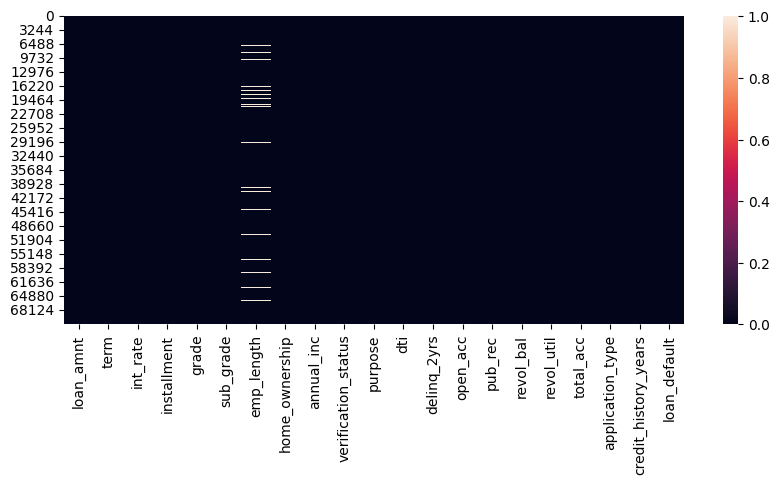

In [55]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull())
plt.show()

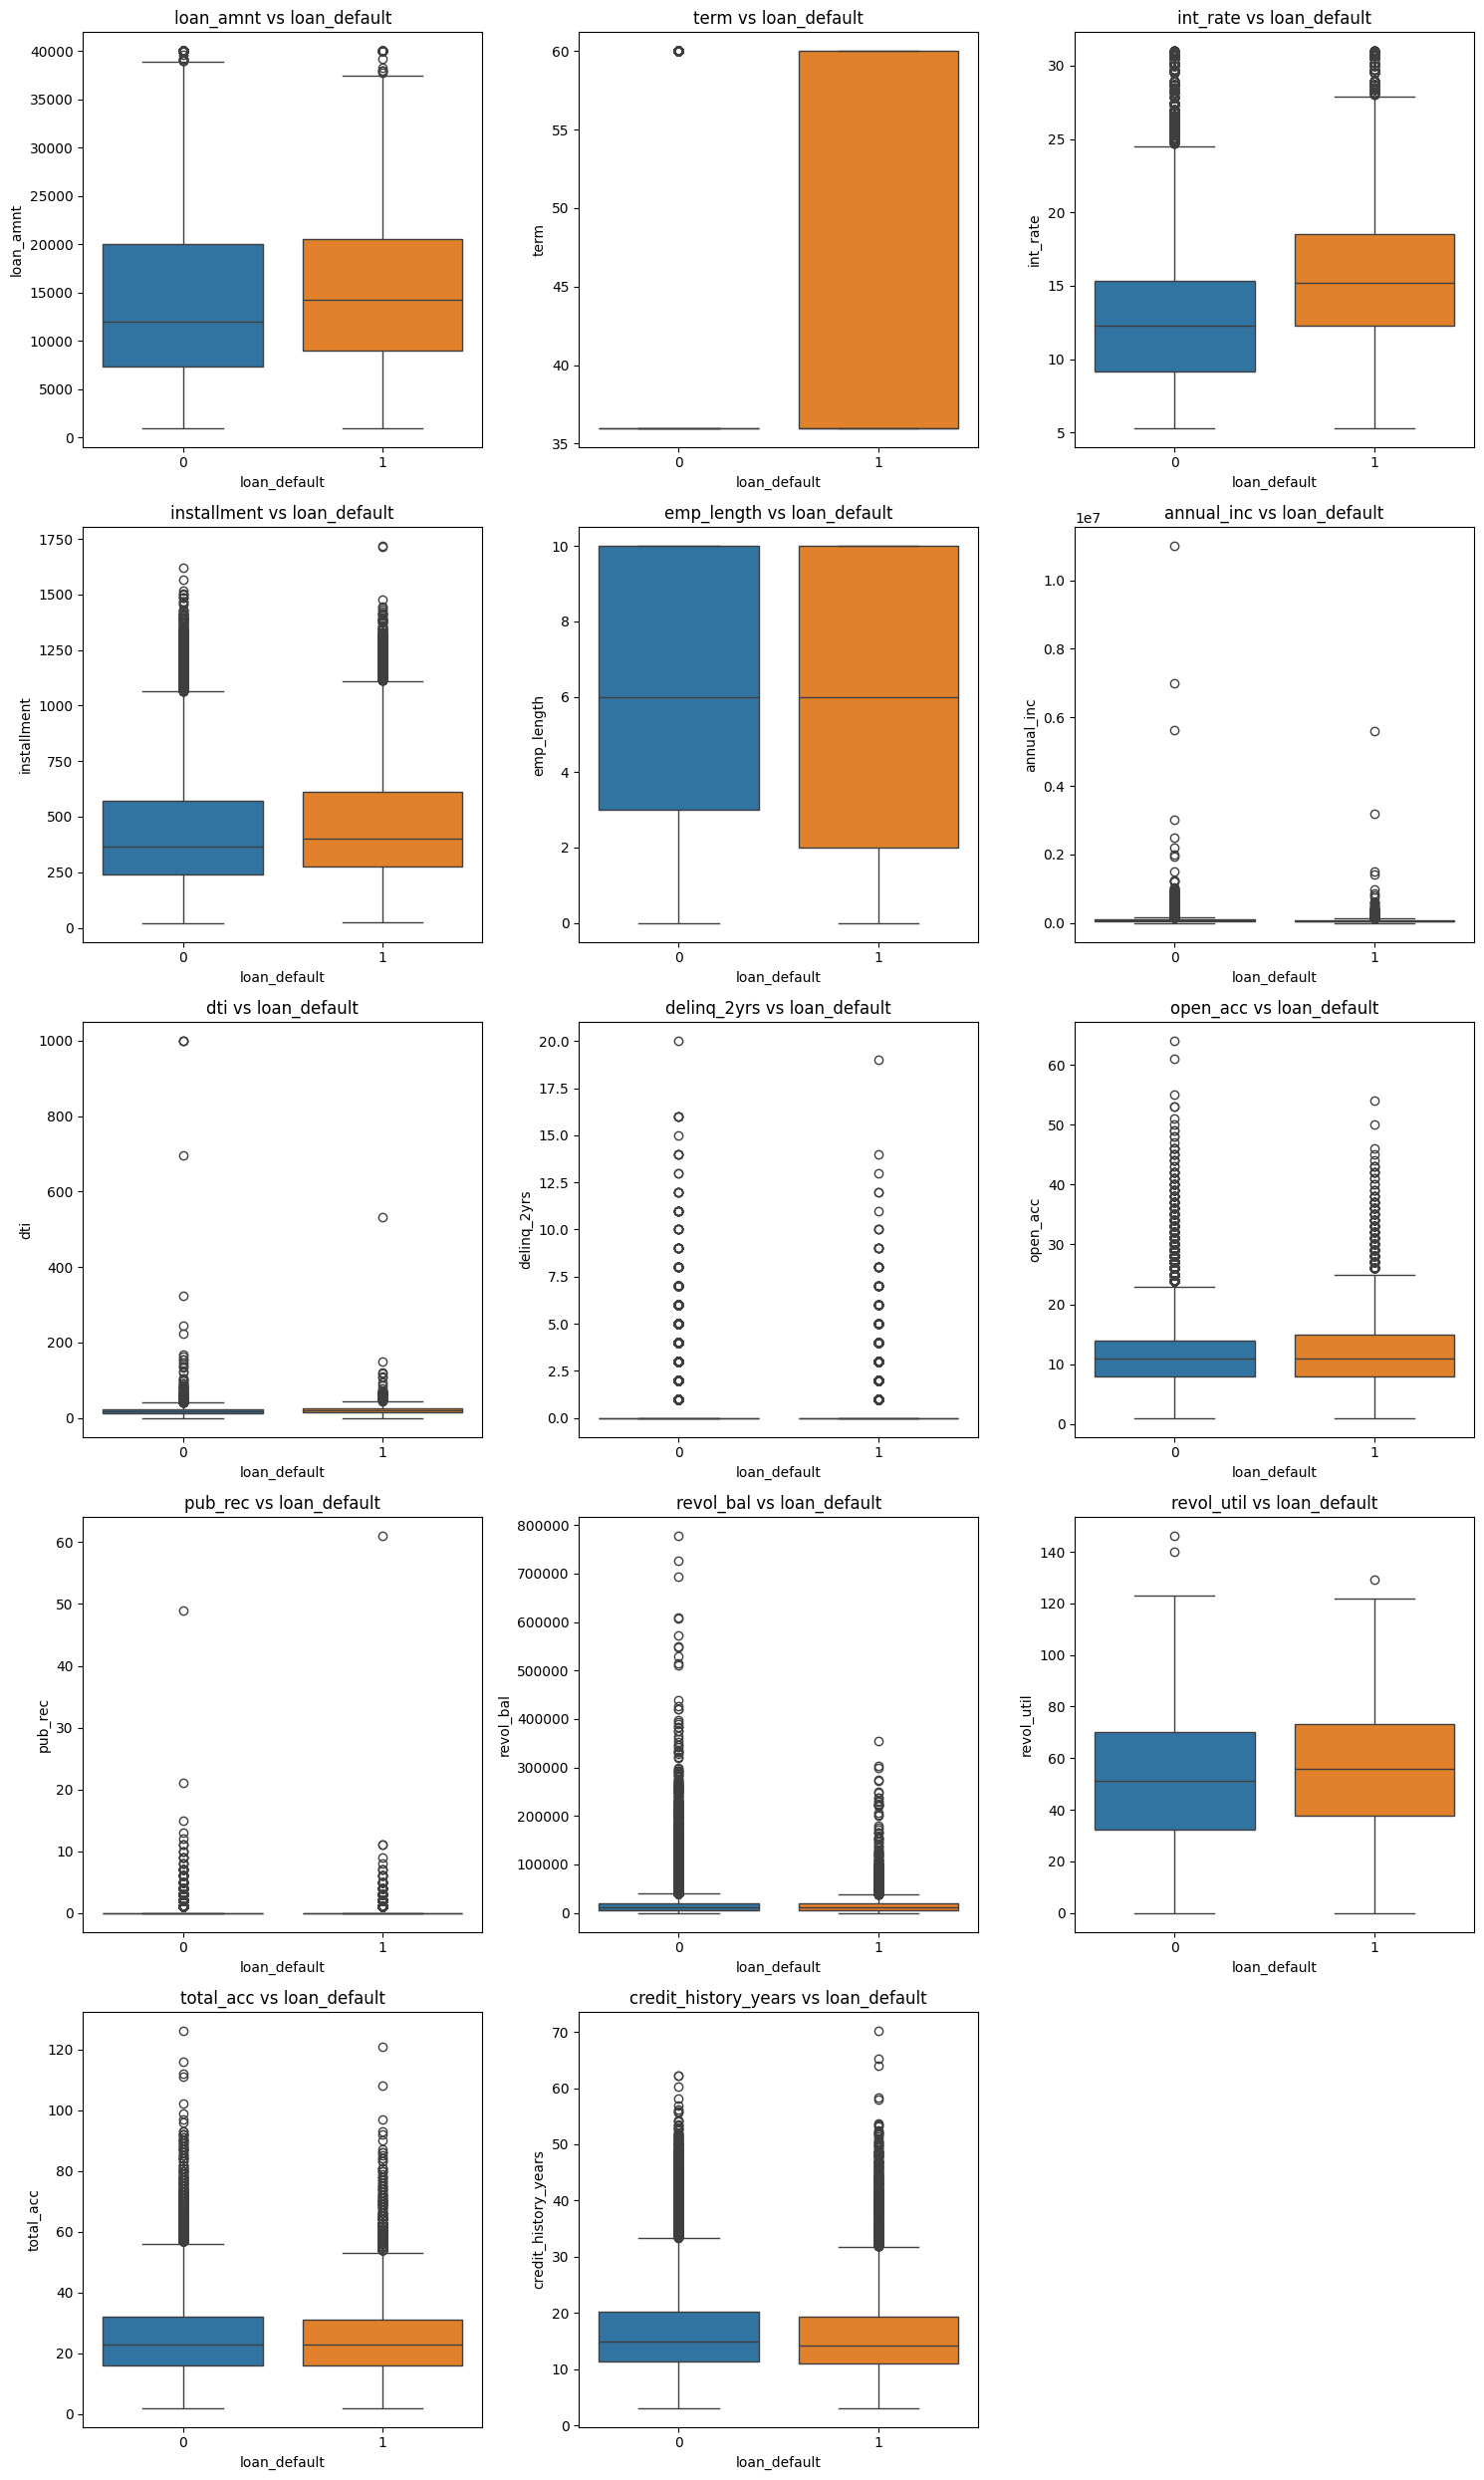

In [59]:
def show_outliers(a, target='loan_default'):

    numerical_cols = a.select_dtypes(include='number').columns
    numerical_cols = numerical_cols.drop(target, errors='ignore')

    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(15, 5 * n_rows)
    )

    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):

        sns.boxplot(
            data=a,
            x=target,
            y=col,
            hue=target,
            legend=False,
            ax=axes[i]
        )

        axes[i].set_title(f'{col} vs {target}')
        axes[i].set_xlabel(target)
        axes[i].set_ylabel(col)

    for i in range(len(numerical_cols), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


show_outliers(df)

In [60]:
def count_outliers_by_class(df, target, num_col):

    result = []

    # Total observations
    total_rows = len(df)

    # Total observations in each class
    class_counts = df[target].value_counts()

    for cls in df[target].dropna().unique():

        data = df.loc[df[target] == cls, num_col].dropna()

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Identify outliers
        outlier_mask = (data < lower) | (data > upper)

        outliers = outlier_mask.sum()

        # Total outliers across ALL classes will be calculated later
        result.append({
            'Class': cls,
            'Total': len(data),
            'Class_%_Of_Total': round(
                class_counts[cls] / total_rows * 100, 2
            ),
            'Q1': Q1,
            'Q3': Q3,
            'Lower_Bound': lower,
            'Upper_Bound': upper,
            'Outlier_Range': f'< {lower:.2f} OR > {upper:.2f}',
            'Outliers': outliers,
            'Outlier_%_Within_Class': round(
                outliers / len(data) * 100, 2
            )
        })

    result = pd.DataFrame(result)

    # Total number of outliers across all classes
    total_outliers = result['Outliers'].sum()

    # Percentage of all outliers belonging to each class
    result['Outlier_%_Of_All_Outliers'] = round(
        result['Outliers'] / total_outliers * 100, 2
    )

    return result

In [61]:
numerical_cols = df.select_dtypes(include='number').columns
numerical_cols = numerical_cols.drop('loan_default')

for col in numerical_cols:

    print(f"\n{'='*50}")
    print(f"Feature: {col}")
    print(f"{'='*50}")

    display(
        count_outliers_by_class(
            df,
            'loan_default',
            col
        )
    )


Feature: loan_amnt


,Class,Total,Class_%_Of_Total,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Range,Outliers,Outlier_%_Within_Class,Outlier_%_Of_All_Outliers
0,0,56909,79.76,7375.0,20000.0,-11562.5,38937.5,< -11562.50 OR > 38937.50,275,0.48,79.71
1,1,14439,20.24,9000.0,20500.0,-8250.0,37750.0,< -8250.00 OR > 37750.00,70,0.48,20.29



Feature: term


,Class,Total,Class_%_Of_Total,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Range,Outliers,Outlier_%_Within_Class,Outlier_%_Of_All_Outliers
0,0,56909,79.76,36.0,36.0,36.0,36.0,< 36.00 OR > 36.00,11544,20.29,100.0
1,1,14439,20.24,36.0,60.0,0.0,96.0,< 0.00 OR > 96.00,0,0.00,0.0



Feature: int_rate


...

,Class,Total,Class_%_Of_Total,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Range,Outliers,Outlier_%_Within_Class,Outlier_%_Of_All_Outliers
0,0,56878,79.76,32.2,70.2,-24.8,127.2,< -24.80 OR > 127.20,2,0.00,66.67
1,1,14433,20.24,37.8,73.2,-15.3,126.3,< -15.30 OR > 126.30,1,0.01,33.33



Feature: total_acc


,Class,Total,Class_%_Of_Total,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Range,Outliers,Outlier_%_Within_Class,Outlier_%_Of_All_Outliers
0,0,56909,79.76,16.0,32.0,-8.0,56.0,< -8.00 OR > 56.00,882,1.55,72.12
1,1,14439,20.24,16.0,31.0,-6.5,53.5,< -6.50 OR > 53.50,341,2.36,27.88



Feature: credit_history_years


,Class,Total,Class_%_Of_Total,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Range,Outliers,Outlier_%_Within_Class,Outlier_%_Of_All_Outliers
0,0,56909,79.76,11.331964,20.167009,-1.920602,33.419576,< -1.92 OR > 33.42,1710,3.00,75.87
1,1,14439,20.24,10.913073,19.252567,-1.596167,31.761807,< -1.60 OR > 31.76,544,3.77,24.13


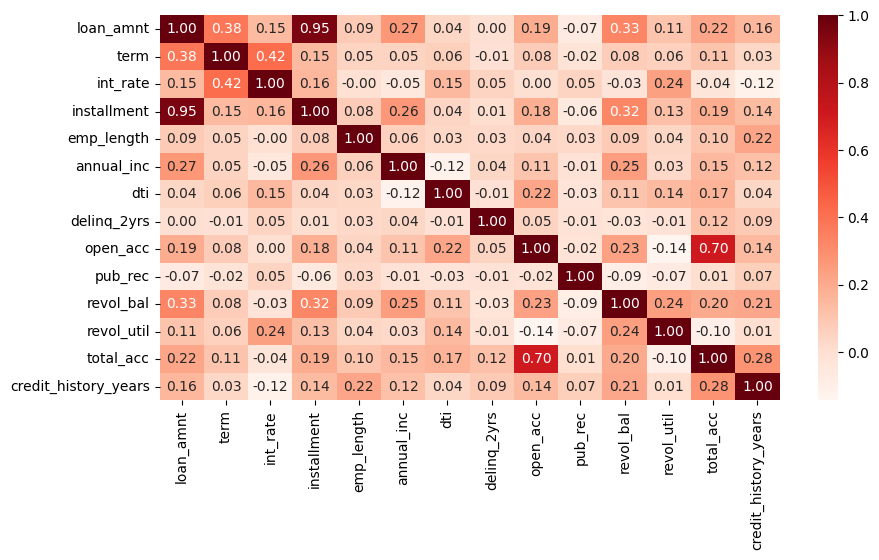

In [74]:
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='Reds',
    fmt='.2f'
)
plt.show()